# Risultati, statistiche e performance di ItalianClassification

Per la valutazione viene usato lo stesso modello e lo stesso split di test registrato nei metadati del file `.joblib` prodotto da `scripts/training_lgbmclassifier.py`.

In questo modo la valutazione mostrata qui rimane coerente con `scripts/evaluate_model.py`: stessa soglia, stesso `test_csv`, stesso report testuale e stesse metriche finali.

## Caricamento del modello


In [27]:
import os
import sys

import joblib
import pandas as pd
from sklearn.inspection import permutation_importance

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.blocks.classifiers import QualityClassifier

model_path = os.path.join(project_root, "models", "lgbm_quality_model.joblib")
artifact = joblib.load(model_path)
training_metadata = artifact.get("training_metadata", {})
threshold = artifact.get("threshold") or training_metadata.get("validation_threshold") or 0.65
test_csv = training_metadata.get("test_csv") or os.path.join(project_root, "data", "splits", "doc_stats_test.csv")

if not os.path.exists(test_csv):
    raise FileNotFoundError(f"Dataset di test non trovato: {test_csv}")

print("\nCaricamento modello...")
classifier = QualityClassifier(model_path=model_path, threshold=threshold)
print("Modello caricato con successo!")
print(f"Threshold in uso: {threshold}")
print(f"Test CSV in uso: {test_csv}")
if training_metadata:
    print("Split di training trovati nel modello:")
    print(f"   Source: {training_metadata.get('source_csv')}")
    print(f"   Train:  {training_metadata.get('train_csv')}")
    print(f"   Val:    {training_metadata.get('validation_csv')}")
    print(f"   Test:   {training_metadata.get('test_csv')}")
    # print(f"   Split_metadata:  {classifier.split_metadata}")


Caricamento modello...
Modello caricato con successo!
Threshold in uso: 0.65
Test CSV in uso: /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv
Split di training trovati nel modello:
   Source: /home/stefano/ita-llm-pipeline/output/feature/doc_stats_per_file.csv
   Train:  /home/stefano/ita-llm-pipeline/data/splits/doc_stats_train.csv
   Val:    /home/stefano/ita-llm-pipeline/data/splits/doc_stats_val.csv
   Test:   /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv


## Valutazione tramite metriche ottenute in evaluation.py

Si mostrano le seguenti metriche:
+ L'accuratezza del modello è misurata come la proporzione dele classificazioni corrette sopra alla totalità delle classificazioni.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
+ $$Precision = \frac{TP}{TP + FP}$$
+ $$Recall = \frac{TP}{TP + FN}$$
+ $$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [28]:
from src.blocks.evaluation import evaluate_model

print("\nValutazione in corso...")
result = evaluate_model(
    classifier=classifier,
    csv_path=test_csv,
    label_column="label",
    output_dir=None # oppure output_dir="evaluatione" se vuoi salvare
)
print("\nValutazione completata con successo!")

X, y, _ =classifier._load_labeled_dataset(
    csv_path=test_csv,
    feature_names=classifier.feature_names,
    label_column="label",
)
X_scaled = pd.DataFrame(
    classifier.scaler.transform(X),
    columns=classifier.feature_names,
    index=X.index,
)

model = classifier.model
feature_names = classifier.feature_names
cm = result["confusion_matrix"]
report_dict = result["classification_report"]


Valutazione in corso...

REPORT DI VALUTAZIONE DEL MODELLO
Dataset: /home/stefano/ita-llm-pipeline/data/splits/doc_stats_test.csv
Modello: /home/stefano/ita-llm-pipeline/models/lgbm_quality_model.joblib
Soglia: 0.65
Timestamp: 2026-04-24 22:54:11

--------------------------------------------------------------------------------
METRICHE GLOBALI
--------------------------------------------------------------------------------
Accuracy:          0.9189 (91.89%)
Balanced Accuracy: 0.8813 (88.13%)
F1-Score:          0.8529
ROC-AUC:           0.9705

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------
                Predicted:Bad  Predicted:Good
Actual:Bad          2251              59
Actual:Good          208             774

Valutazione completata con successo!


## Calcolo e visualizzazione della Permutation Importance relative alle feature utilizzate

L'importance è la metrica che misura quanto la realtiva feature contribuisce alla capacità del modello di predire, quindi misura quanto la feature è utile alla costruzione degli alberi decisionali nel nostro caso. Tramite questa metrica si identificano le feature che guidano maggiormente le predizioni del modello. 

Di seguito vengono mostrate le prime 10 feature per importanza del modello utilizzato nel progetto. 

In [29]:
perm = permutation_importance(
    classifier.model,
    X_scaled,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": classifier.feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values(by="importance_mean", ascending=False)
    
print("\n" + "=" * 80)
print("TOP 10 FEATURES (Feature Importance)")
print("-" * 80)
for _, row in importance_df.head(10).iterrows():
    importance_pct = (row["importance_mean"] / importance_df["importance_mean"].sum()) * 100
    bar_length = int(importance_pct / 2)
    bar = "█" * bar_length
    print(f"{row['feature']:30s} {bar:40s} {importance_pct:6.2f}% "
          f"(±{row['importance_std']:.4f})")
print("\n" + "=" * 80)


TOP 10 FEATURES (Feature Importance)
--------------------------------------------------------------------------------
avg_line_length                ██████████████                            29.22% (±0.0049)
stopword_ratio                 █████████                                 18.94% (±0.0054)
language_score                 ███                                        6.47% (±0.0038)
avg_word_length                ██                                         4.15% (±0.0013)
exclamation_ratio              ██                                         4.15% (±0.0026)
consonant_ratio                █                                          3.29% (±0.0025)
white_space_ratio              █                                          2.97% (±0.0019)
line_count                     █                                          2.84% (±0.0023)
parenthesis_ratio              █                                          2.75% (±0.0016)
digit_ratio                    █                                       

## Confusion Matrix

Nella matrice di confusione vengono mostrati tutti i campioni `Positive` sulla prima riga della matrice e tutti i campioni `Negative` sulla seconda riga. Questi vengono divisi come: `TP` (True Positive) in posizione (0,0), `FP` (False Positive) in posizione (0,1), `FN` in posizione (1,0), `TN` in posizione (1,1).

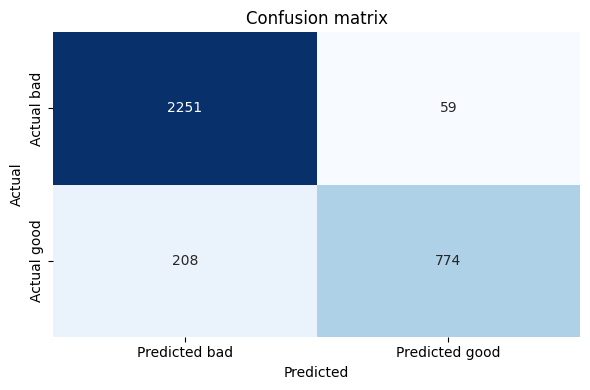

In [30]:
import seaborn as sns

cm_df = pd.DataFrame(
    cm,
    index=["Actual bad", "Actual good"],
    columns=["Predicted bad", "Predicted good"],
)
# print("\n\tConfusion matrix")
# display(cm_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## Correlation Matrix



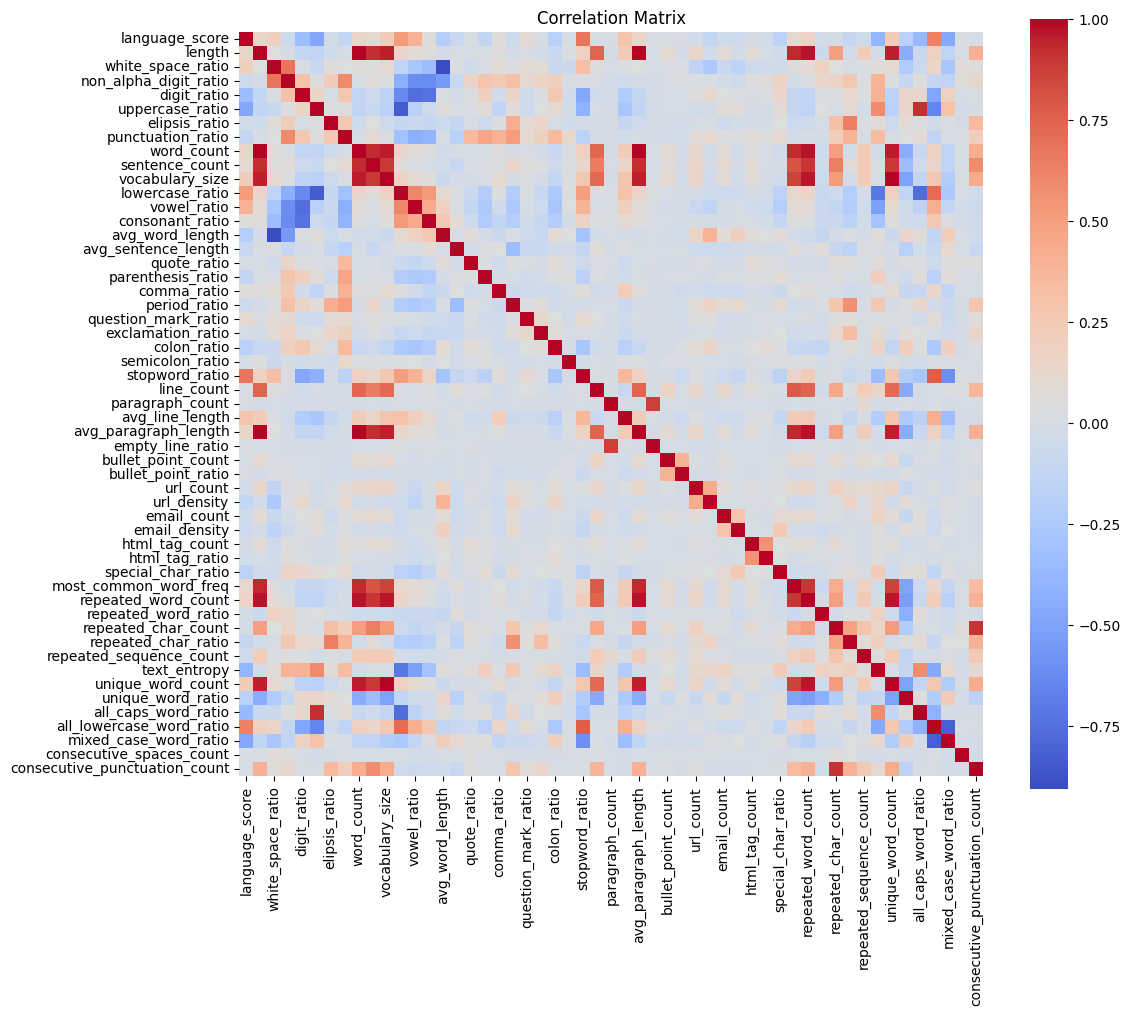

In [31]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_scaled.corr(), annot=False, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

## Cross-validation

Calcolo le curve ROC-AUC e Precision-Recall relative ai diversi Fold utilizzati per la cross-validation.

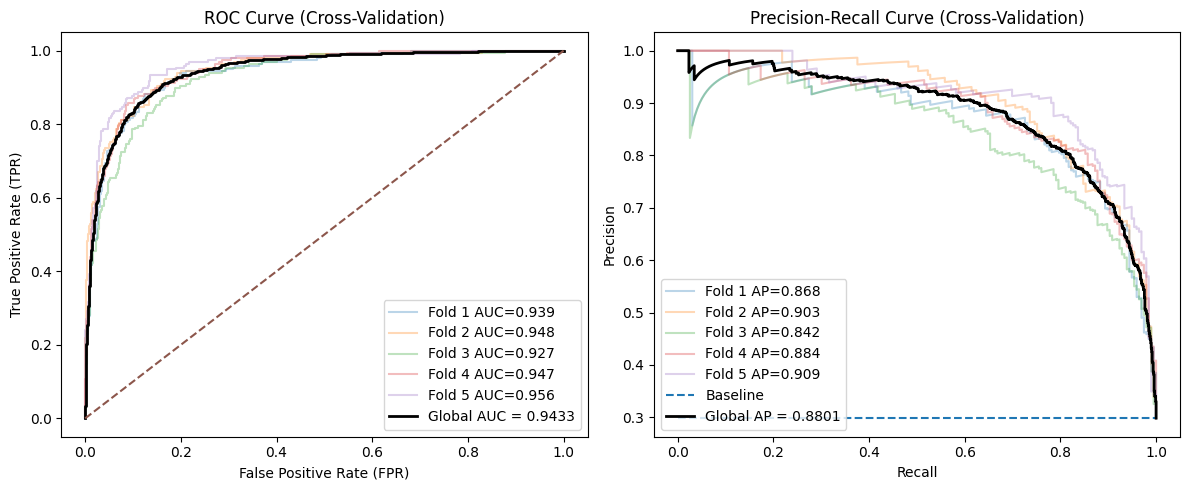

In [32]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

# ===== INPUT =====
# model: (es. LGBM)
# X, y: dataset

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# per aggregare risultati
y_true_all = []
y_scores_all = []

# per visualizzare fold singoli (opzionale)
plt.figure(figsize=(12, 5))

# ===== CROSS VALIDATION =====
for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # fit
    model.fit(X_train, y_train)

    # probabilità
    y_scores = model.predict_proba(X_val)[:, 1]

    # salva per aggregazione globale
    y_true_all.extend(y_val)
    y_scores_all.extend(y_scores)

    # ROC fold (opzionale)
    fpr, tpr, _ = roc_curve(y_val, y_scores)
    roc_auc = roc_auc_score(y_val, y_scores)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, alpha=0.3, label=f"Fold {i+1} AUC={roc_auc:.3f}")

    # PR fold (opzionale)
    precision, recall, _ = precision_recall_curve(y_val, y_scores)
    pr_auc = average_precision_score(y_val, y_scores)

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, alpha=0.3, label=f"Fold {i+1} AP={pr_auc:.3f}")


# ===== METRICHE GLOBALI =====
y_true_all = np.array(y_true_all)
y_scores_all = np.array(y_scores_all)

# ROC globale
fpr, tpr, _ = roc_curve(y_true_all, y_scores_all)
roc_auc = roc_auc_score(y_true_all, y_scores_all)

# PR globale
precision, recall, _ = precision_recall_curve(y_true_all, y_scores_all)
pr_auc = average_precision_score(y_true_all, y_scores_all)

# ===== PLOT FINALE =====

# ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color="black", linewidth=2, label=f"Global AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve (Cross-Validation)")
plt.legend()

# PR
plt.subplot(1, 2, 2)
baseline = np.mean(y_true_all)
plt.hlines(baseline, 0, 1, linestyles="--", label="Baseline")

plt.plot(recall, precision, color="black", linewidth=2, label=f"Global AP = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Cross-Validation)")
plt.legend()

plt.tight_layout()
plt.show()

## Summary Plot of the features

/home/stefano/ita-llm-pipeline/datatrove_venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


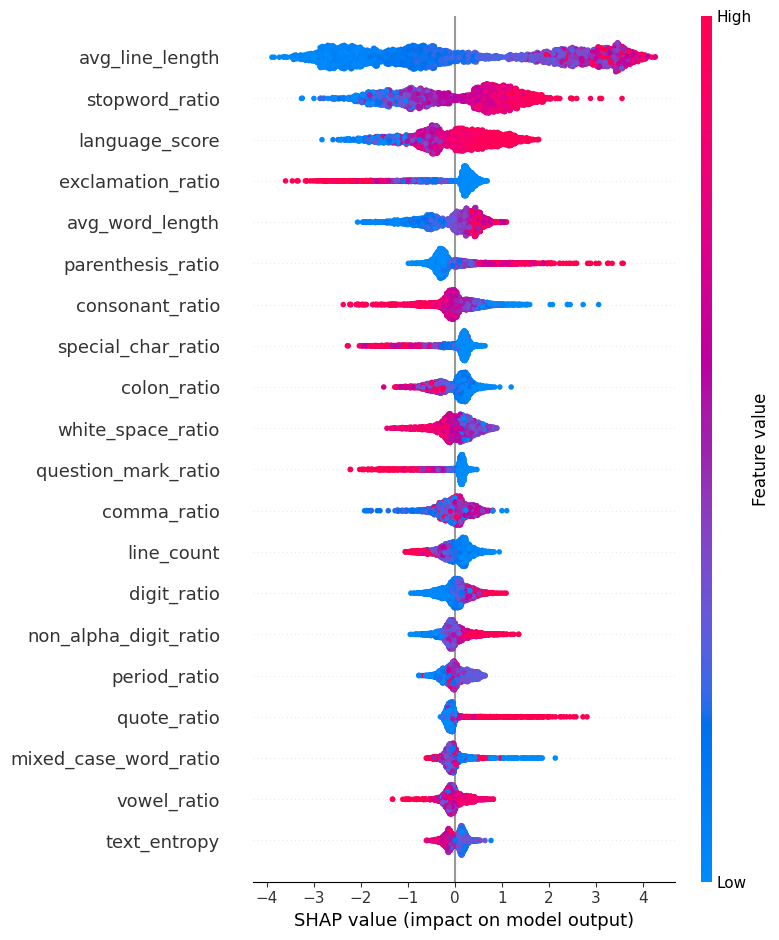

In [33]:
import shap

# model = tuo modello LGBM già addestrato
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)
shap_values_good = shap_values[1]
shap_values_bad = shap_values[0]

shap.summary_plot(shap_values, X)


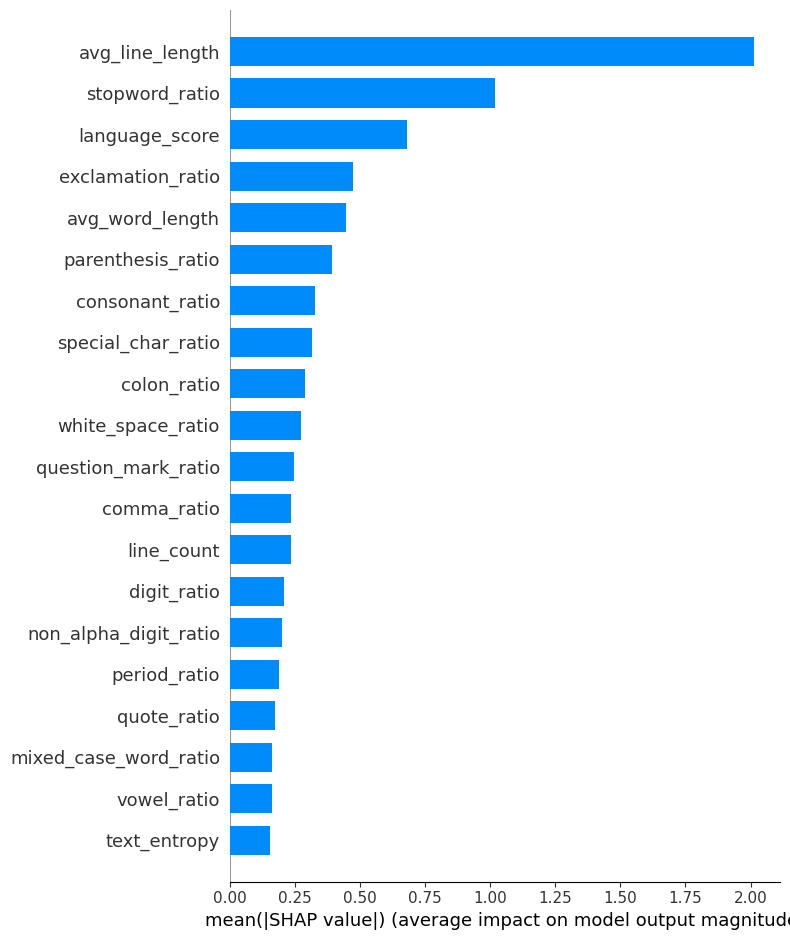

In [34]:
shap.summary_plot(shap_values, X, plot_type="bar")